In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from ipywidgets import interact, IntSlider
from IPython.display import HTML
from scipy.stats import norm as gaussian
from matplotlib.animation import FuncAnimation

In [2]:
np.random.seed(42)

# Quantum Harmonic Oscillator

We have a particle in a harmonic potential

$$V(x) = \frac{1}{2}m\omega^2 x^2$$

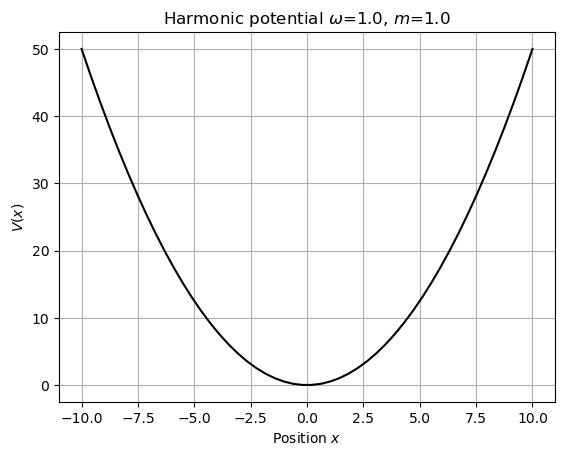

In [3]:
m = 1.0
omega = 1.0
x = np.linspace(-10, 10)
V = 0.5 * m * (omega ** 2) * (x ** 2)

plt.plot(x, V, color='black', label=r"V(x) = \frac{1}{2}m\omega^2 x^2")
plt.title(rf"Harmonic potential $\omega$={omega}, $m$={m}")
plt.xlabel(r"Position $x$"); plt.ylabel(r"$V(x)$")
plt.grid()
plt.show()

The the state of the particle is governed by the *time-independent* Schrodinger equation

$$\begin{aligned}
    H\psi &= E\psi\\
    \Big(-\frac{\hbar}{2m}\frac{\partial^2}{\partial x^2} + \frac{1}{2}m\omega x^2\Big) \psi &= E\,\psi
\end{aligned}$$

For simplicity, we consider the case where $\hbar = m = \omega = 1$.

## Solution to the schrodinger equation

We have 

$$\frac{\partial^2 \psi}{\partial x^2} + \big(E - \frac{1}{2}x^2 \big)\psi = 0$$

For larger values of $x^2$ (or $x\to \pm \infty$) the term ${\large \frac{1}{2}x^2}$ dominates and the equation reduces to

$$\frac{\partial^2}{\partial x^2}\psi_\infty  - \frac{1}{2}x^2 \psi_\infty = 0$$

Such an equation could have a solution of the form

$$\psi_\infty(x) = {\large e^{-\lambda x^2}}$$ with $\lambda > 0$. Substituting into the above equation we find that $\lambda = 1/2$.

The function $\psi_\infty$ captures only the assymptotic behaviour of the wavefunction. The full havefunction must take the form 
$$ \psi(x) = {\large e^{-\frac{1}{2}x^2}} H(x)$$

Where $H(x)$ should not diverge faster than $\psi_\infty$ decays. A family of function with this property are **polynomials**. 

Let $$H_n(x) = x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0$$

Substituting into the equation we arrive at the **Hermit equation**

$$H^{\prime\prime} - 2xH^\prime + (2E - 1)H = 0$$

Again, for large values of $x$ the term $x^n$ dominates and the Hermit equation reduces to 
$$\Big[-2n + (2E -1)\Big]x^2 = 0$$

Because $x\neq0$ we find that available energies take the form 

$$\boxed{E_n = n + { \frac{1}{2}}}$$

### Hermite Polynomials

We suppose the Hermit polynomials take the form

$$H_n(x) = x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0$$

The coefficients can be computed using the following recursion
$$\begin{aligned}
    a_{k} &= \frac{(k + 1) (k + 2)}{2 (k - n)}\; a_{k+2}\\
\end{aligned}$$
and base cases
$$\begin{aligned}
    a_{n} &= 1\\
    a_{n-1} &= 0
\end{aligned}$$

where $k = n-2,\, n-4, \dots$. This gives the following procedure

In [4]:
def harmonic_hermit_coefs(energy_level: int) -> NDArray:
    """
    Computes the Hermit polynomial solutions of the schrodinger equation for a particle in a harmonic trap.
    The polynomials take the form

        H(x) = x^n + a[n-1] x^(n-1) + ... + a[1]x + a[0]

    Parameters
    ----------
    energy : int (non negative)
        Quantum number n (non-negative integer) determining the energy level.

    Returns
    -------
    NDArray of shape (n, )
        The polynomical coefficients corresponding to the given energy level.
        The i-th element of the array corresponds to the i-th coefficient.
    """
    if energy_level < 0:
        raise Exception("Particle can't have negative energy")
    n = energy_level
    coefs = np.zeros(n + 1)
    coefs[n] = 1.0
    for k in range(n - 2, 0, -2):
        num = (k + 1) * (k + 2)
        den = 2 * (k - n)
        coefs[k] = (num / den) * coefs[k + 2]
    return coefs

Having the above procedure we can calculate the harmit polynomials at specific values

In [5]:
def harmonic_wavefuntion(energy_level: int, x: NDArray):
    """
    Evaluate quantum harmonic oscillator wavefunctions.
    
    Parameters
    ----------
    energy_level : int
        Quantum number n (n = 0, 1, 2, ...) specifying the energy state.
    x : NDArray
        Position values where the wavefunction is evaluated.
    
    Returns
    -------
    NDArray
        Wavefunction ψ_n(x) = e^{-x²/2} H_n(x), where H_n is the nth
        Hermite polynomial.
    """
    coefs = harmonic_hermit_coefs(energy_level)
    H = np.polyval(np.flip(coefs), x)
    psi =  np.exp(-0.5 * x ** 2) * H
    return psi / np.sqrt(np.trapezoid(psi ** 2, x))

### Solution visualization

Now we can visualize all the wavefunctions

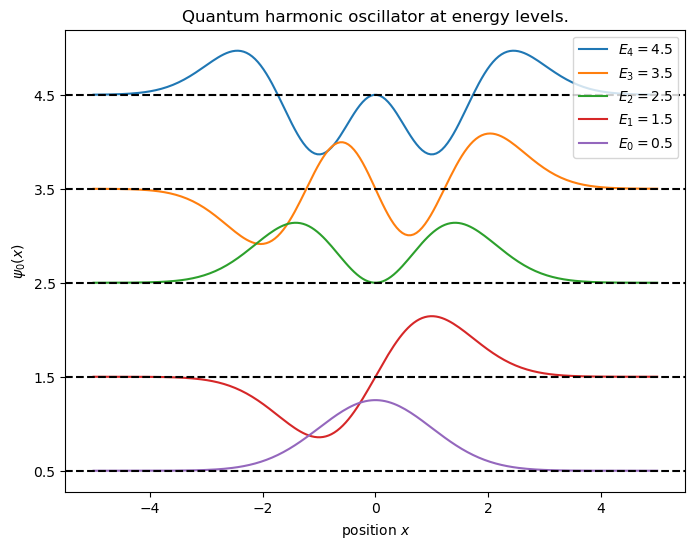

In [6]:
energy_levels = range(5)
x = np.linspace(-5, 5, 200)
plt.figure(figsize=(8, 6))
for n in reversed(energy_levels):
    E = n + 0.5
    psi = harmonic_wavefuntion(n, x) + E
    plt.plot(x, psi, label=rf'$E_{{{n}}} = {n + 0.5}$')
    plt.axhline(E, linestyle='--', color='black')
plt.xlabel(r'position $x$')
plt.ylabel(rf'$\psi_{{{n}}}(x)$')
plt.title(rf'Quantum harmonic oscillator at energy levels.')
plt.legend(loc='upper right')
plt.yticks([n + 0.5 for n in energy_levels])
plt.show()

# Quantum *Statistical Mechanics*

In quantum statistical mechanics, in addition to the probabilty $|\psi_n(x)|^2$ of finding a particle at position $x$ there is a probability $\pi(n)$ of a particle being at energy level $E_n$, given by the Boltzman distribution

$$\pi(x) \propto \exp\big\{-\frac{E_n}{k_B\, T} \big\} = \exp\big\{-\beta\,E_n \big\}$$

where $\beta = {\large \frac{1}{k_B\,T}}$.

The joint probability of being at positon $x$ **and** at energy level $E_n$ is proportional to the product

$$\pi(x, n) \propto \psi_n(x)\,\exp\big\{-\beta\,E_n \big\} \,\psi^*_n(x)$$

## Desity Matrix

The above expression for the joint probability leads nohere. That's why we introduce the *diagonal* **density matrix** $\rho(x, x^\prime;\, beta)$ such that

$$\pi(x) \propto \rho(x,x;\,\beta) = \sum_n \psi_n(x)\,\exp\big\{-\beta\,E_n \big\} \,\psi^*_n(x)$$

The **nondiagonal** density matrix is defined as

$$\rho(x, x^\prime;\; \beta) = \sum_n \psi_n(x)\,\exp\big\{-\beta\,E_n \big\} \,\psi^*_n(x^\prime)$$

This is the central object of quantum statistical mechanics.

## Properties of the denstiy matrix
The density matrix has some realy interesting properties.

### Partition function

The partition function at some $\beta$ is given by

$$Z(\beta) = \mathrm{Tr} \rho = \int_{x \in \mathbb{R}} dx \rho(x,x;\,\beta)$$

(Can be proven easily)

### Convolution (Matrix Squaring)
We can use the following property to compute a denstiy matrix at lower temperature (higher $\beta$) given a density matrix at higher temperature
$$\int dx^\prime \rho(x, x^\prime;\,\beta_1)\; \rho(x^\prime, x^{\prime\prime};\,\beta_2) = \rho(x, x^{\prime\prime};\, \beta_1 + \beta_2)$$

(Can be proven easily)

### Free density matrix
The density matrix for a system with no potential is called **free density matrix** and is given by the closed form expression

$$\rho^\text{free}(x, x^\prime;\,\beta) = \frac{1}{\sqrt{2\pi\beta}}\;\exp\Big\{-\frac{(x - x^\prime)^2}{2\beta}\Big\}$$

In [7]:
def scalar_free_density_matrix(x: float, xp: float, beta: float) -> float:
    """
    Computes the free density matrix

    Parameters:
    -----------
    x : float
        Position for which to calculate rho_free(x, x', beta).
    xp : float
        Position for which to calculate rho_free(x, x', beta).   
    beta : float
           The inverse temperature parameter.

    Returns
    -------
    float
        The value of the free density matrix rho_free(x, xp, beta)
    """
    return np.exp(-(x - xp) ** 2 / (2 * beta)) / np.sqrt(np.pi)

### Trotter decomposition

This propery concerns the high temperature limit and relates the free density matrix with the *full* density matrix (at some potential). For a system at high temperature, with hamiltonian given by

$$H = H^\text{free} + V(x) = -\frac{1}{2}\frac{\partial^2}{\partial x^2} + V(x)$$

the full density matrix is given by

$$\rho(x,x^\prime;\,\beta) = \large e^{-\frac{\beta}{2} V(x)}\;\rho^\text{free}(x, x^\prime;\, \beta)\;e^{-\frac{\beta}{2} V(x^\prime)}$$

## Feynman path integral

We can apply the convolution property multiple times to get

$$\rho(x_0,x_0;\,\beta) = \int dx_1 dx_2 \dots dx_{N-1}
                          \rho(x_0, x_1;\,\frac{\beta}{N})\;
                          \rho(x_1, x_2;\,\frac{\beta}{N})\;
                          \rho(x_{\small N-1}, x_0;\,\frac{\beta}{N})$$

To get the partition function we have to integrate one more time

$$\begin{aligned}
Z(\beta) &= \int dx_0 \rho(x_0,x_0;\,\beta)\\
&= \int dx_0 dx_1 dx_2 \dots dx_{N-1}
        \rho(x_0, x_1;\,\frac{\beta}{N})\;
        \rho(x_1, x_2;\,\frac{\beta}{N})\;
        \rho(x_{\small N-1}, x_0;\,\frac{\beta}{N})
\end{aligned}$$

The values $x_k$ form a path

$$\mathbf{x} = \Big(x_0,\, x_1,\dots,x_{\small N-1},\,x_0 \Big)$$

in **imaginary time** ${\large \tau = \frac{k \beta}{N}}$.

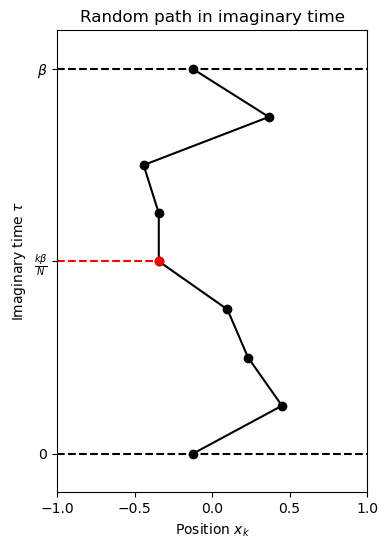

In [8]:
beta = 0.1
N, k = 8, 4
x_min, x_max = -1.0, 1.0
tau = np.linspace(0, beta, N + 1)
x = np.linspace(x_min, x_max)
path = np.random.uniform(-0.5, 0.5, N + 1); 
# Enforce perioc boundary conditions
path[-1] = path[0]


# plot result
plt.figure(figsize=(4,6))
plt.plot(path, tau, '-o', color='black')
plt.axhline(beta, linestyle='--', color='black')
plt.axhline(0.0, linestyle='--', color='black')
plt.plot([path[k]], [tau[k]], 'o', color='red')
plt.axhline(tau[k], xmin=0, xmax=(path[k] - x_min)/(x_max - x_min), linestyle='--', color='red')
plt.xlabel(r"Position $x_k$")
plt.ylabel(r"Imaginary time $\tau$")
plt.yticks([0, tau[k], beta], ['0', r'$\frac{k\beta}{N}$', r'$\beta$'])
plt.xlim(-1, 1); plt.ylim(-beta/10, beta + beta/10)
plt.title("Random path in imaginary time")
plt.show()

### Monte Carlo sampling

1. We choose a point $x_k$ at random.
2. We form a new point $x^\prime_k = x_k + \delta$, where delta in a uniform random number.
3. We accept the move with **Metropolis acceptance probability**

This gives the following program for the harmonic oscillator

In [9]:
def naive_harmonic_path(x: np.ndarray, # (N, )
                        beta: float,
                        delta: float = 1,
                        n_steps: int = 1_000_000,
                       ) -> list[float]:
    N = x.shape[0]
    Delta_t = beta / N
    paths = []
    for step in range(n_steps):
        k = np.random.randint(0, N)
        prv = (k - 1) % N
        nxt = (k + 1) % N
        dx = np.random.uniform(-delta, delta)
        pi_a = scalar_free_density_matrix(x[prv], x[k], Delta_t) \
             * scalar_free_density_matrix(x[k], x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * x[k] ** 2)
        pi_b = scalar_free_density_matrix(x[prv], x[k] + dx, Delta_t) \
             * scalar_free_density_matrix(x[k] + dx, x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * (x[k] + dx) ** 2)
        Upsilon = pi_b / pi_a if pi_a != 0 else np.float(1.0)
        if np.random.rand() < Upsilon:
            x[k] += dx
            paths.append(x.copy())
    return paths

In [58]:
import os, shutil, subprocess
from numba import prange
from tqdm import tqdm
from IPython.display import display, Video

# Set parameters
N = 10
beta = 1.0
N, k = 8, 4
x_min, x_max = -2.0, 2.0
n_frames = 20 * 10

# Imaginary time, position, and potential
tau = np.linspace(0, beta, N)
pos = np.linspace(x_min, x_max)
pot = 0.5 * pos ** 2

# Sample system
x0 = np.zeros(N)
paths = naive_harmonic_path(x0, beta, n_steps=1_000)

# Keep only relevant frames
if n_frames < len(paths):
    step = len(paths) // (n_frames - 1)
    frames = range(0, step * (n_frames - 1) + 1, step)
else:
    frames = range(len(paths))

# Create dir to save the frames
os.makedirs("frames", exist_ok=True)

# Plot results for every frame
print(f"Rendering {len(frames)} frames...")
for frame in tqdm(frames, desc='rendering frames', total=len(frames)):
    # Get path and histogram for i-th path
    p = paths[frame]
    xs = np.concat(paths[ : frame + 1])
    fig, ax = plt.subplots(2, 1, figsize=(6.4, 6))  # 2 rows, 1 column
    mu, sigma = xs.mean(), xs.std()
    pi = gaussian.pdf(pos, loc=mu, scale=sigma)
    ## Plot path
    ax[0].plot(p, tau, '-o', color='black', label='path')
    ax[0].plot(pos, pot, '--', color='black', label=r'$V(c)$')
    ax[0].set_xlim(x_min, x_max)
    ax[0].set_ylim(0.0, beta)
    ax[0].set_xlabel(r'Position $x_k$')
    ## Plot histogram
    ax[1].hist(xs, color='white', edgecolor='blue', density=True, label='histogram')
    ax[1].plot(pos, pi, color='red', label='estimated gaussial')
    ax[1].set_xlim(x_min, x_max)
    ax[1].set_xlabel(r'Position $x$')
    ax[1].legend()
    fig.suptitle("Path integral sampling")
    # Control and save plot
    fig.savefig(f"frames/frame_{frame:04d}.png", dpi=100, bbox_inches="tight")
    plt.close(fig)
print("Done.")

# Create animation
print("Rendering animation...", end='')
subprocess.run(
    [
        "ffmpeg",
        "-framerate", "20",
        "-i", "frames/frame_%04d.png",
        "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
        "-c:v", "libx264",
        "-crf", "20",
        "-pix_fmt", "yuv420p",
        "-y",  # overwrite output if exists
        "path_integral_sampling.mp4"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=True
)
print("done.")
print("Cleaning frames directory...", end='')
shutil.rmtree("frames")
print('done.')

display(Video("path_integral_sampling.mp4", embed=True))

Rendering 200 frames...


rendering frames: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:27<00:00,  7.24it/s]


Done.
Rendering animation...done.
Cleaning frames directory...done.
